In [101]:
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [102]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Data exploration

In [103]:
import os
def walk_through_dir(dir_path):
    """Walks though dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [104]:
from pathlib import Path

data_path = Path("data/pizza_sushi_steak/")
walk_through_dir(dir_path=data_path)

There are 2 directories and 0 images in data\pizza_sushi_steak
There are 3 directories and 0 images in data\pizza_sushi_steak\test
There are 0 directories and 25 images in data\pizza_sushi_steak\test\pizza
There are 0 directories and 19 images in data\pizza_sushi_steak\test\steak
There are 0 directories and 31 images in data\pizza_sushi_steak\test\sushi
There are 3 directories and 0 images in data\pizza_sushi_steak\train
There are 0 directories and 78 images in data\pizza_sushi_steak\train\pizza
There are 0 directories and 75 images in data\pizza_sushi_steak\train\steak
There are 0 directories and 72 images in data\pizza_sushi_steak\train\sushi


In [105]:
# Setup train test path
train_dir = data_path / 'train'
test_dir = data_path / 'test'

train_dir, test_dir


(WindowsPath('data/pizza_sushi_steak/train'),
 WindowsPath('data/pizza_sushi_steak/test'))

### 1.1 Visualizing image

data\pizza_sushi_steak\test\sushi\2394442.jpg
Random image path: data\pizza_sushi_steak\test\sushi\2394442.jpg
Image class: sushi


Text(0.5, 1.0, 'Image class: sushi | Image shape: torch.Size([3, 408, 512])')

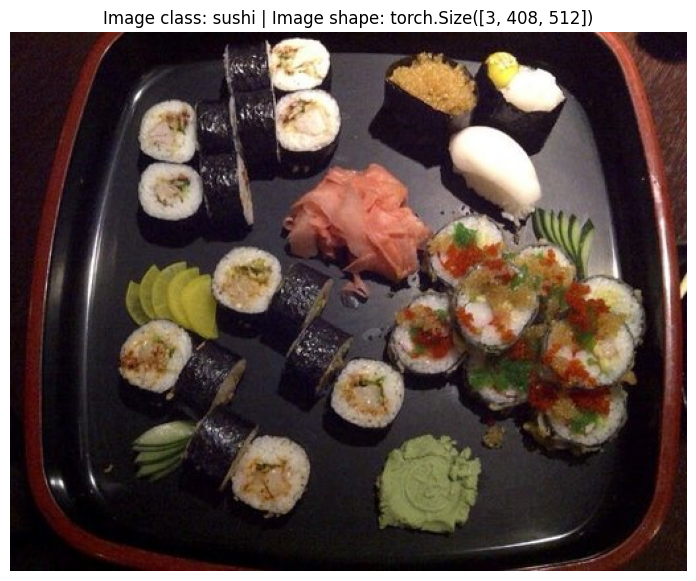

In [106]:
import random
from torchvision.io import read_image
import matplotlib.pyplot as plt
# Set seed
random.seed(42)

# 1. Get all image paths
image_path_list = list(data_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name
image_class = random_image_path.parent.stem
image_class

# 4. Open image
img = read_image(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1,2,0))
plt.axis(False)
plt.title(f"Image class: {image_class} | Image shape: {img.shape}")

## 2. Transforming data

In [107]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [108]:
# Write a transfor for image
data_transform = transforms.Compose([ # Or nn.Sequential
    transforms.ToTensor(),
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(0.5),
])

data_transform

Compose(
    ToTensor()
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
)

In [109]:
type(img)

torch.Tensor

In [110]:
img_np = img.permute((1,2,0)).numpy()
data_transform(img_np).shape

torch.Size([3, 64, 64])

### 2.1 Visualize transform data

In [185]:
def plot_transformed_image(image_paths: list, transform, n=3, seed=None):
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_paths, k=n)
    for image_path in random_image_path:
        img = read_image(image_path).permute((1,2,0)).numpy()
        fig, ax = plt.subplots(1,2)
        ax[0].imshow(img)
        ax[0].set_title(f"Original")
        ax[0].axis(False)

        # Transform and plot target image
        transormed_image = transform(img)
        ax[1].imshow(transormed_image.permute((1,2,0)))
        ax[1].set_title(f"Transformed")
        ax[1].axis(False)

        fig.suptitle(f"Class: {image_path.parent.stem}")

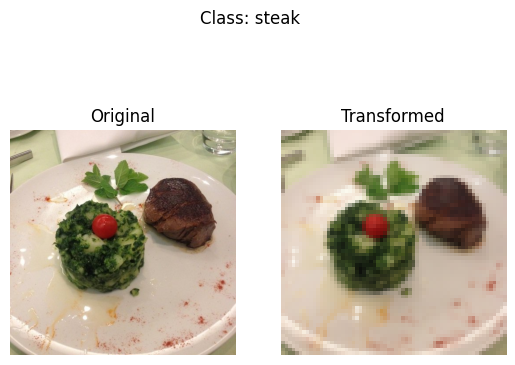

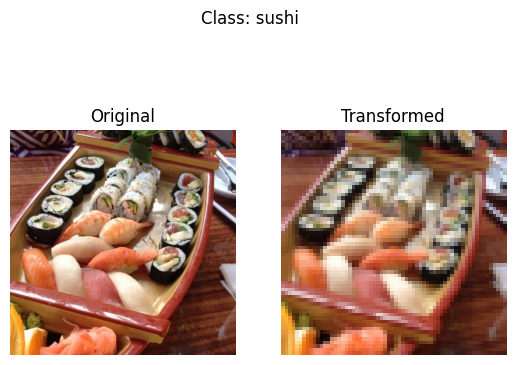

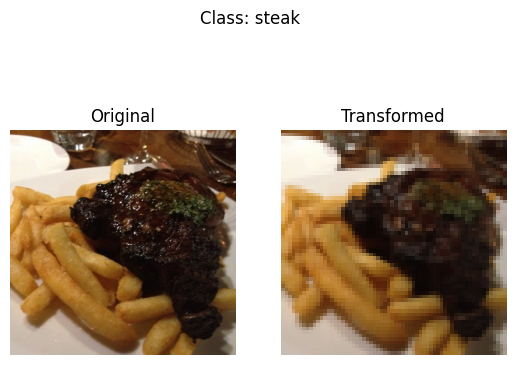

In [186]:
plot_transformed_image(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

## 3. Option1: Loading image data usin `ImageFolder`

In [187]:
# Use ImageFolser to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                transform=data_transform,
                                target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                    transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_sushi_steak\train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_sushi_steak\test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
            ))

In [188]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [189]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [190]:
len(train_data), len(test_data)

(225, 75)

In [191]:
train_data.samples[:3]

[('data\\pizza_sushi_steak\\train\\pizza\\1008844.jpg', 0),
 ('data\\pizza_sushi_steak\\train\\pizza\\1033251.jpg', 0),
 ('data\\pizza_sushi_steak\\train\\pizza\\1044789.jpg', 0)]

In [192]:
img, label = train_data[0]
img.shape, label

(torch.Size([3, 64, 64]), 0)

In [193]:
class_names[label]

'pizza'

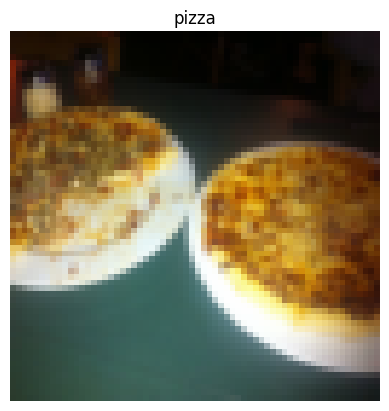

In [194]:
plt.imshow(img.permute((1,2,0)))
plt.title(class_names[label])
plt.axis('off');

### 3.1 Turn images into `Dataloader`

In [195]:
import os
os.cpu_count()/2

10.0

In [196]:
# Turn train and test datasets into DataLoader
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                                    batch_size=1,
                                    num_workers=1, #OR os.cpu_count(),
                                    shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                                    batch_size=1,
                                    num_workers=1,
                                    shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x25724f3c530>,
 <torch.utils.data.dataloader.DataLoader at 0x2572235d2e0>)

In [197]:
len(train_dataloader) == len(train_data)

True

In [198]:
len(test_dataloader) == len(test_data)

True

In [199]:
img, label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

## 4. Option 2: Loading Image Data with a custom `Dataset`

In [200]:
import os
import cv2 as cv
from torchvision.io import read_image
from torch.utils.data import Dataset
from torchvision import transforms

In [201]:
print(f"Target dir: {train_dir}")

list(os.scandir(train_dir))

Target dir: data\pizza_sushi_steak\train


[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [202]:
class_names_found = sorted([entry.name for entry in list(os.scandir(train_dir))])
class_names_found

['pizza', 'steak', 'sushi']

In [203]:
def find_classes(directory: str) -> tuple[list[str], dict[str, int]]:
    # 1. Get the class names by scanning the target directory
    classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
    
    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}")
    
    # 3. Create a dictionary of index label
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [204]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 4.1 Create a custm `Dataset` 

In [205]:
# Write a custom dataset class
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None):
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int):
        image_path = self.paths[index]
        return read_image(image_path)
        # img = cv.imread(image_path)
        # return cv.cvtColor(img, cv.COLOR_BGR2RGB)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index: int):
        img = self.load_image(index)
        class_name = self.paths[index].parent.name 
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img.permute(1,2,0).numpy()), class_idx
            # return self.transform(img), class_idx
        else:
            return img, class_idx

In [206]:
# Create a transfom
train_tranforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5)
])

test_tranforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(64, 64))
])

In [207]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                        transform=train_tranforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                        transform=test_tranforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x257232a1100>,
 <__main__.ImageFolderCustom at 0x257222d73e0>)

In [208]:
len(train_data), len(train_data_custom)

(225, 225)

In [209]:
len(test_data), len(test_data_custom)

(75, 75)

In [210]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [211]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

### 4.2 Function for display random images

In [212]:
def display_random_images(dataset: torch.utils.data.Dataset,
                            classes: list[str] = None,
                            n :int = 10,
                            seed: int = None):
    if n > 10:
        n = 10
    
    if seed:
        random.seed(seed)
    
    random_sample_idx = random.sample(range(len(dataset)), k=n)

    fig, axes = plt.subplots(1, n, figsize=(10,8))

    for i, targ_sample in enumerate(random_sample_idx):
        targ_image, targ_label = dataset[targ_sample]
    
        targ_image_adjust = targ_image.permute(1, 2, 0)

        axes[i].imshow(targ_image_adjust)
        axes[i].axis('off')
        if classes :
            title = f"Classes: {classes[targ_label]}"
        axes[i].set_title(title)

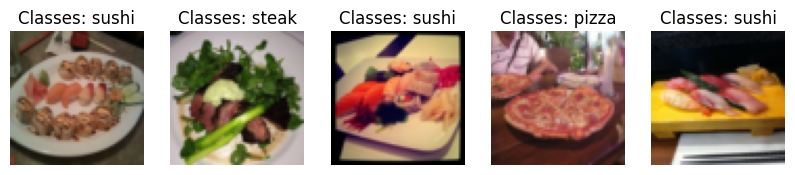

In [213]:
# Display random images from train_data
display_random_images(train_data, 
                        n=5,
                        classes=class_names,
                        seed=None)

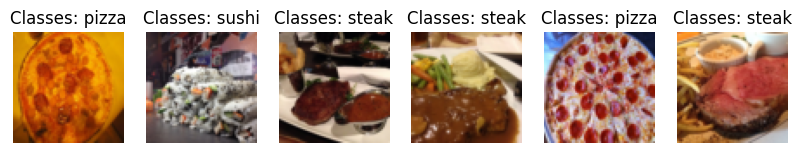

In [214]:
# Display random images from train_data_custom
display_random_images(train_data_custom, 
                        n=6,
                        classes=class_names,
                        seed=None)

### 4.3 Turn custom loaded iamges into `DataLoader`

In [215]:
from torch.utils.data import DataLoader

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                        batch_size=32,
                                        num_workers=0,
                                        shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                        batch_size=32,
                                        num_workers=0,
                                        shuffle=False)
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x257230a9a60>,
 <torch.utils.data.dataloader.DataLoader at 0x2572398ea80>)

In [216]:
img_custom, label_custom = next(iter(train_dataloader_custom))
print(img_custom.shape, label_custom.shape)

torch.Size([32, 3, 64, 64]) torch.Size([32])


## 5. Other forms of transforms (data augmentation)

In [232]:
train_tranform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

test_tranform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [233]:
image_path_list[:10]

[WindowsPath('data/pizza_sushi_steak/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_sushi_steak/test/pizza/2124579.jpg')]

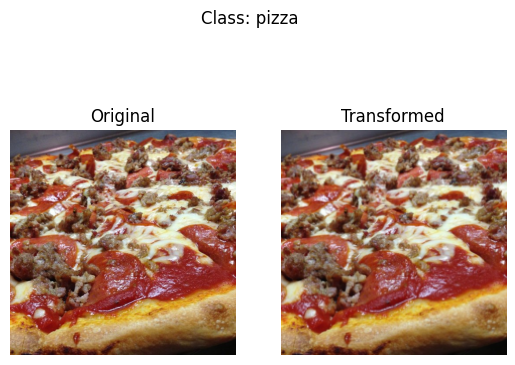

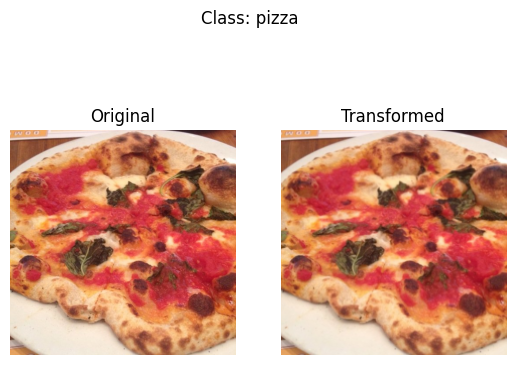

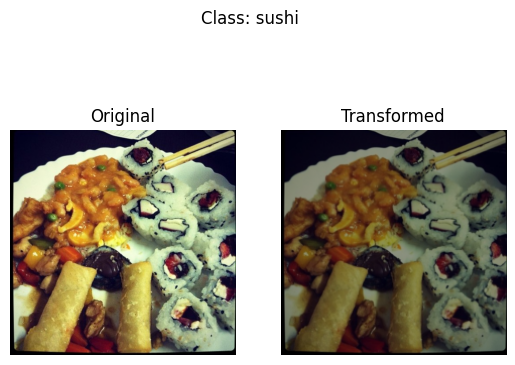

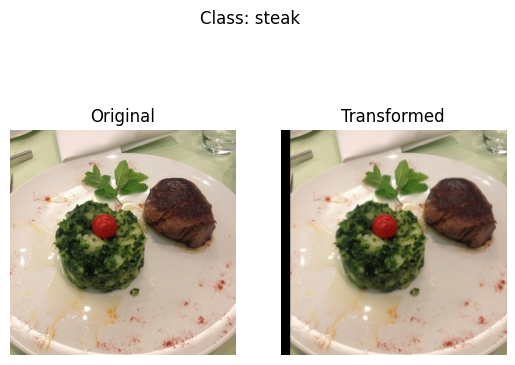

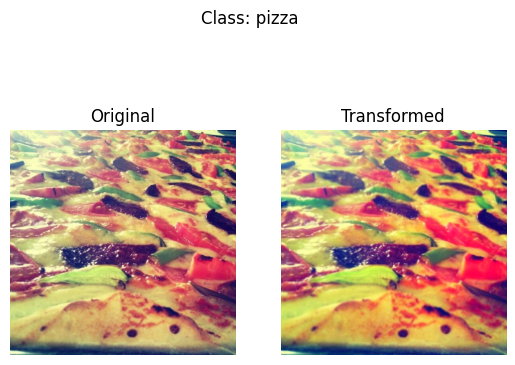

In [234]:
plot_transformed_image(image_path_list, train_tranform, n=5, seed=None)